# Comparison of Autoregressive Generative Models

Goal:
Compare VAN, PixelCNN, LSTM and Transformer architectures in terms of:

- convergence speed
- variational free energy
- effective sample size
- energy statistics
- sampling speed
- computational cost

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

In [27]:
comparison_df = pd.read_csv("../results/tables/final_models/comparison_table.csv")

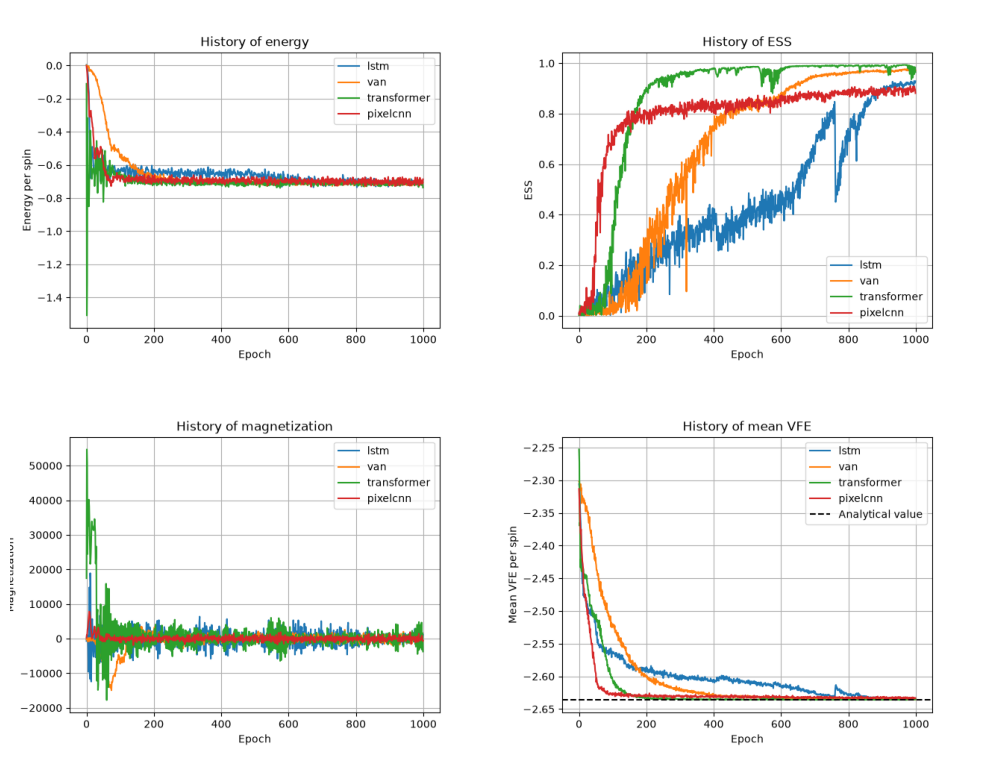

In [28]:
img1 = mpimg.imread("../results/figures/final_models/models_Energy.png")
img2 = mpimg.imread("../results/figures/final_models/models_ESS.png")
img3 = mpimg.imread("../results/figures/final_models/models_Magnetization.png")
img4 = mpimg.imread("../results/figures/final_models/models_VFE.png")

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0, 0].imshow(img1)
axes[0, 1].imshow(img2)
axes[1, 0].imshow(img3)
axes[1, 1].imshow(img4)

for ax in axes.flat:
    ax.axis("off")

plt.tight_layout()
plt.show()

The figures compare diffrent neural network architectures with themselves in Energy per spin, Magnetization, mean VFE per spin and ESS value.

#### Energy

All models eventually converge to a similar energy range, approximately between `-0.68` and `-0.72` per spin, which suggests that they learn configurations with comparable average energy after sufficient training.

The main differences are visible during the early stages of training. VAN converges more slowly than the other architectures and requires roughly 200 epochs before reaching the same energy region.

LSTM and PixelCNN converge faster and show relatively smooth behaviour after the initial phase. Their energy values stabilize early and remain close to each other for most of the training.

The Transformer shows the largest initial fluctuations, including a strong negative spike at the beginning of training. However, these fluctuations decrease quickly and the model later stabilizes in the same energy range as the other architectures.

Overall, the architectures differ mainly in convergence speed and early-training stability, while their final energy per spin values are very similar.

#### Magnetization

The largest differences between the architectures appear during the early stages of training. The Transformer shows the strongest fluctuations, reaching very large positive and negative magnetization values before gradually stabilizing.

LSTM also exhibits noticeable early fluctuations, although they are substantially smaller than those of the Transformer. VAN initially moves toward negative magnetization before converging toward the same region as the other models.

PixelCNN shows the most stable behaviour, with comparatively small fluctuations throughout training.

After roughly 150 epochs, all models fluctuate around a similar magnetization level close to zero This suggests that their generated samples become more balanced with respect to positive and negative spins.

Overall, the main difference between the architectures is the stability of magnetization during early training, while their long-term behaviour becomes similar.

#### Mean VFE per spin

PixelCNN shows fastest conversion speed especially in first 50 epochs to later stabilize around analitical value.

Transformer also convergers quickly and aproaches analitical value faster than VAN and LSTM.

In first 50 epochs LSTM model strongly converge similar to Transforter to later slow down and reach analitical value at around 850 epoch.

VAN architecture converges steadly to reach analitical value around 400 epoch.

Overall, all models eventually converge to similar mean VFE after around 850 epochs, with similar fluctuations value. 
The main diffrence remains their convergance speed.

#### ESS value

PixelCNN improves the fastest at the beginning of training and quickly reaches an ESS of around `0.8`, after which the improvement becomes much slower.

The Transformer also converges quickly and eventually achieves the highest ESS, reaching values close to `1.0`.

VAN improves more gradually. After training it also reaches a high ESS, close to the Transformer.

LSTM shows the slowest and most unstable improvement. Its ESS increases gradually and exhibits several noticeable drops during training before reaching values close to `0.9`.

Overall, the Transformer achieves the best final ESS, while PixelCNN learns fastest during the early stages of training.

In [29]:
comparison_df["Model"] = comparison_df["Model"].str.strip(to_strip="[]''")
comparison_df.set_index("Model", inplace=True)
comparison_df

,Mean_vfe,Std_vfe,VFE_abs_err,Mean_ESS,Std_ESS,Nb_of_params,Time_to_generate_samples,Training epochs
Model,,,,,,,,
transformer,-2.634910,0.000317,0.000992,0.959089,0.001879,54337,1.704755,1000
lstm,-2.633827,0.000480,0.002075,0.922628,0.004500,9046,0.503861,1000
pixelcnn,-2.632983,0.000811,0.002919,0.899292,0.003615,207233,0.891203,1000
van,-2.635120,0.000300,0.000783,0.970338,0.002037,8320,0.307426,1000


The final evaluation shows that all four models achieve very similar mean VFE values close to the analytical reference, but they differ in sampling quality, model size and computational cost.

VAN achieves the lowest VFE absolute error (`0.000783`) and the highest mean ESS (`0.9703`) while also having the smallest number of parameters (`8,320`) and the fastest sample generation time (`0.307 s`).

The Transformer also performs very well, with a VFE error of `0.000992` and mean ESS of `0.9591`, but it is considerably more computationally expensive, with `54,337` parameters and the longest sampling time (`1.705 s`).

LSTM achieves slightly worse VFE accuracy (`0.002075`) and mean ESS (`0.9226`), but remains relatively lightweight with only `9,046` parameters.

PixelCNN has the largest model size (`207,233` parameters) and achieves the lowest mean ESS (`0.8993`) among the tested architectures, while its VFE error remains relatively small (`0.002919`).

Overall, VAN provides the strongest trade-off between VFE accuracy, ESS, model size and sampling speed in this experiment, while the Transformer achieves similarly strong sampling quality at a substantially higher computational cost.

# Hiperparameters analysis

## Transformer

In [30]:
transformer_analysis = pd.read_csv('../results/tables/hiperparam_test/Transformer.csv')
transformer_analysis["Model"] = transformer_analysis["Model"].str.strip(to_strip="[]''")
transformer_analysis.set_index("Model", inplace=True)
transformer_analysis

,Mean_vfe,Std_vfe,VFE_abs_err,Mean_ESS,Std_ESS,Nb_of_params,Time_to_generate_samples,Training epochs
Model,,,,,,,,
batch_size256,-2.555837,0.005374,0.080065,0.096895,0.062698,54337,1.190312,200
batch_size512,-2.625688,0.001469,0.010214,0.677675,0.023461,54337,1.199672,200
batch_size1024,-2.630374,0.000734,0.005529,0.805275,0.008191,54337,1.199690,200
emb_dim32,-2.629838,0.000781,0.006065,0.793820,0.013372,14881,1.198426,200
emb_dim64,-2.630900,0.000718,0.005003,0.825220,0.008137,54337,1.197914,200
emb_dim48,-2.629523,0.000783,0.006379,0.780307,0.017913,31537,1.200265,200
num_heads2,-2.629112,0.000757,0.006791,0.767973,0.010254,54337,0.936862,200
num_heads4,-2.631263,0.000681,0.004639,0.835336,0.007283,54337,1.203375,200
num_heads8,-2.633694,0.000390,0.002209,0.923519,0.003110,54337,1.690326,200


#### Analysis of embedding dim

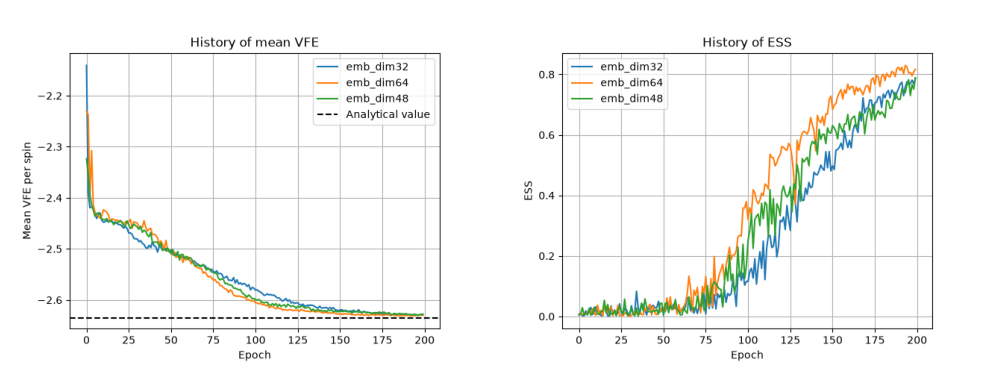

In [31]:
img1 = mpimg.imread("../results/figures/hiperparam_test/Embedding dimensions (transfrm)_vfe.png")
img2 = mpimg.imread("../results/figures/hiperparam_test/Embedding dimensions (transfrm)_ESS.png")

fig, axes = plt.subplots(1, 2, figsize=(10, 8))

axes[0].imshow(img1)
axes[1].imshow(img2)

for ax in axes.flat:
    ax.axis("off")

plt.tight_layout()
plt.show()

The figures show how the embedding dimension affects the VFE and ESS of the Transformer model.

All tested configurations show a similar VFE convergence pattern and reach comparable final values close to the analytical reference.

The configuration with embedding dimension 64 achieves the fastest ESS improvement and reaches the highest ESS values during training.

In [32]:
transformer_analysis.loc[['emb_dim32', 'emb_dim64', 'emb_dim48'], ['Mean_vfe', 'Std_vfe', 'VFE_abs_err', 'Mean_ESS', 'Std_ESS']]

,Mean_vfe,Std_vfe,VFE_abs_err,Mean_ESS,Std_ESS
Model,,,,,
emb_dim32,-2.629838,0.000781,0.006065,0.793820,0.013372
emb_dim64,-2.630900,0.000718,0.005003,0.825220,0.008137
emb_dim48,-2.629523,0.000783,0.006379,0.780307,0.017913


All configuration characterize with similar mean VFE and standard deviation of VFE regardless of embedding size.

Model with embedding dimension of 64 resuted in highest mean ESS and smallest standard deviation of tested configurations

What interesting embedding dimension of 48 resulted in worse Mean ESS and STD than embedding dimension of 32

Overall, embedding dimension has a relatively small effect on final VFE, but embedding dimension 64 provides the best ESS behaviour among the tested configurations.

#### Analysis of num heads

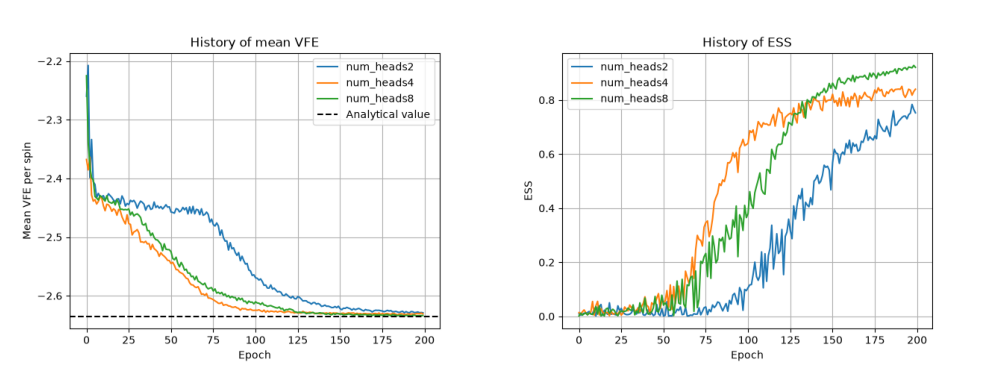

In [33]:
img1 = mpimg.imread("../results/figures/hiperparam_test/Number of Heads (transfrm)_vfe.png")
img2 = mpimg.imread("../results/figures/hiperparam_test/Number of Heads (transfrm)_ESS.png")

fig, axes = plt.subplots(1, 2, figsize=(10, 8))

axes[0].imshow(img1)
axes[1].imshow(img2)

for ax in axes.flat:
    ax.axis("off")

plt.tight_layout()
plt.show()

Presented figures show how diffrent number of attention heads affects Mean VFE and ESS of tranformer model.

All models acquire simmilar mean VFE convergence in 200 epochs 

Model with smallest number of attention heads (2) characterizes with slowest convergence in mean VFE. Its ESS value is also the smallest compared to other configuraitons.

Model with 4  attention heads presents fastest convergence in mean VFE and achieves higher final ESS than model with 2 attention heads.

Configuration with 8 attention heads has slighty slower convergence than model with 4 attention heads but characterizes with best ESS compared to all tested configurations

In [34]:
transformer_analysis.loc[['num_heads2', 'num_heads4', 'num_heads8'], ['Mean_vfe', 'Std_vfe', 'VFE_abs_err', 'Mean_ESS', 'Std_ESS']]

,Mean_vfe,Std_vfe,VFE_abs_err,Mean_ESS,Std_ESS
Model,,,,,
num_heads2,-2.629112,0.000757,0.006791,0.767973,0.010254
num_heads4,-2.631263,0.000681,0.004639,0.835336,0.007283
num_heads8,-2.633694,0.000390,0.002209,0.923519,0.003110


The numerical results show that increasing the number of attention heads improves Transformer performance.

The 8-head configuration achieves the lowest VFE error (`0.00221`) and the highest mean ESS (`0.9235`).

It also shows the lowest variability in both VFE and ESS.

Overall, 8 attention heads provide the best performance among the tested configurations.

#### Analysis of batch size

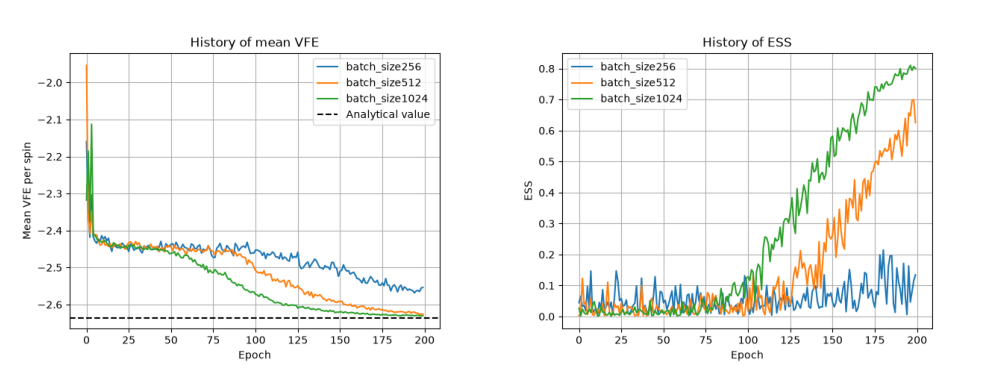

In [35]:
img1 = mpimg.imread("../results/figures/hiperparam_test/Batch size (transfrm)_vfe.png")
img2 = mpimg.imread("../results/figures/hiperparam_test/Batch size (transfrm)_ESS.png")

fig, axes = plt.subplots(1, 2, figsize=(10, 8))

axes[0].imshow(img1)
axes[1].imshow(img2)

for ax in axes.flat:
    ax.axis("off")

plt.tight_layout()
plt.show()

The figures show how batch size affects VFE and ESS in the Transformer model.

All configurations show similar VFE behaviour during the early stages of training. After approximately 50 epochs, larger batch sizes begin to converge faster.

Batch sizes 512 and 1024 reach similar final VFE values, while batch size 256 converges more slowly and remains further from the analytical reference.

For ESS, batch size 1024 performs best throughout the later stages of training, followed by batch size 512. Batch size 256 achieves substantially lower ESS values

In [36]:
transformer_analysis.loc[['batch_size256', 'batch_size512', 'batch_size1024'], ['Mean_vfe', 'Std_vfe', 'VFE_abs_err', 'Mean_ESS', 'Std_ESS']]

,Mean_vfe,Std_vfe,VFE_abs_err,Mean_ESS,Std_ESS
Model,,,,,
batch_size256,-2.555837,0.005374,0.080065,0.096895,0.062698
batch_size512,-2.625688,0.001469,0.010214,0.677675,0.023461
batch_size1024,-2.630374,0.000734,0.005529,0.805275,0.008191


The numerical results confirm the trends observed in the training curves.

Increasing the batch size clearly improves Transformer performance. Batch size 1024 achieves the lowest VFE error (`0.00553`) and the highest mean ESS (`0.8053`).

It also shows the lowest variability in both VFE and ESS.

Overall, batch size 1024 provides the best performance among the tested configurations.

#### Most promising configuration

Based on the individual hyperparameter experiments, the most promising configuration is:

- Batch size: 1024
- Number of attention heads: 8
- Embedding dimension: 64

## PixelCNN

In [37]:
pixelcnn_analysis = pd.read_csv('../results/tables/hiperparam_test/PixelCNN.csv')
pixelcnn_analysis["Model"] = pixelcnn_analysis["Model"].str.strip(to_strip="[]''")
pixelcnn_analysis.set_index("Model", inplace=True)
pixelcnn_analysis

,Mean_vfe,Std_vfe,VFE_abs_err,Mean_ESS,Std_ESS,Nb_of_params,Time_to_generate_samples,Training epochs
Model,,,,,,,,
batch_size128,-2.626698,0.002968,0.009204,0.727551,0.028851,207233,0.469369,500
batch_size256,-2.630681,0.001458,0.005222,0.812827,0.017667,207233,0.465812,500
batch_size516,-2.630944,0.001057,0.004959,0.836761,0.009009,207233,0.891019,500
channels16,-2.628123,0.002466,0.007780,0.756658,0.047472,14177,0.458708,500
channels32,-2.628794,0.002563,0.007108,0.775165,0.022760,53441,0.442164,500
channels64,-2.629260,0.002336,0.006643,0.770732,0.034567,207233,0.467273,500
kernel_size3,-2.589478,0.007334,0.046425,0.239145,0.063922,38273,0.444889,500
kernel_size5,-2.599291,0.005640,0.036611,0.322665,0.051261,105857,0.460652,500
kernel_size7,-2.630060,0.002153,0.005843,0.814918,0.030778,207233,0.470179,500


#### Analysis of number of channels

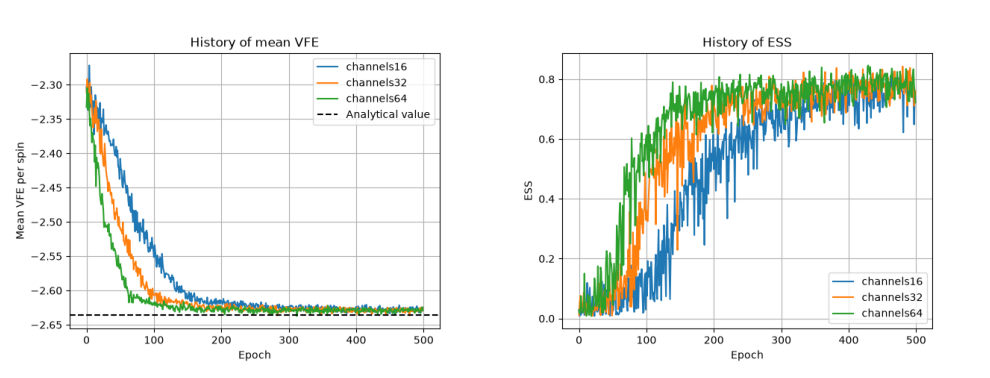

In [38]:
img1 = mpimg.imread("../results/figures/hiperparam_test/Number of channels (pixelcnn)_vfe.png")
img2 = mpimg.imread("../results/figures/hiperparam_test/Number of channels (pixelcnn)_ESS.png")

fig, axes = plt.subplots(1, 2, figsize=(10, 8))

axes[0].imshow(img1)
axes[1].imshow(img2)

for ax in axes.flat:
    ax.axis("off")

plt.tight_layout()
plt.show()

The figures show how number of channels affects VFE and ESS of PixelCNN model

All model configurations converge similarly close to analytical VFE. Model with highest number of channels has the fastes conversion rate.

Similarly to VFE every configuration reaches similar ESS value with 64 channels reaching it the fastest.

In [39]:
pixelcnn_analysis.loc[['channels16', 'channels32', 'channels64'], ['Mean_vfe', 'Std_vfe', 'VFE_abs_err', 'Mean_ESS', 'Std_ESS']]

,Mean_vfe,Std_vfe,VFE_abs_err,Mean_ESS,Std_ESS
Model,,,,,
channels16,-2.628123,0.002466,0.007780,0.756658,0.047472
channels32,-2.628794,0.002563,0.007108,0.775165,0.022760
channels64,-2.629260,0.002336,0.006643,0.770732,0.034567


The numerical results confirm the trends observed in the training curves.

All tested channel sizes achieve very similar final results.

The 64-channel configuration achieves the lowest VFE absolute error (`0.00664`), while the 32-channel configuration reaches the highest mean ESS (`0.7752`).

Overall, increasing the number of channels improves convergence speed, but the final VFE and ESS values remain very similar across the tested configurations.

#### Analysis of kernel size

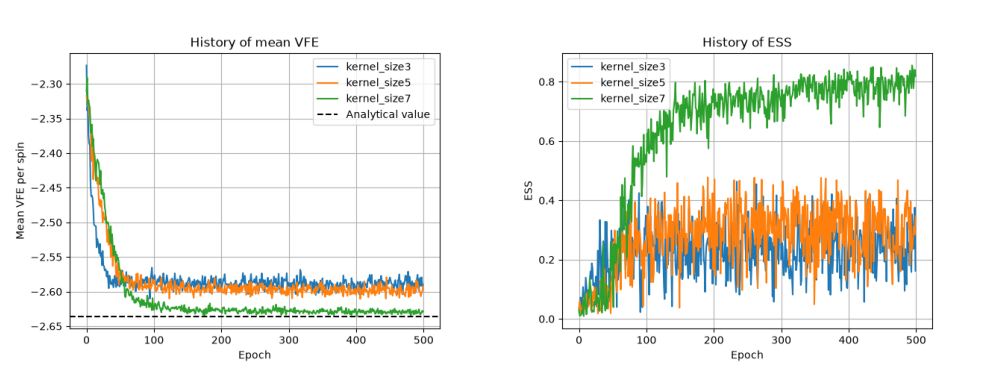

In [40]:
img1 = mpimg.imread("../results/figures/hiperparam_test/Kernel size (pixelcnn)_vfe.png")
img2 = mpimg.imread("../results/figures/hiperparam_test/Kernel size (pixelcnn)_ESS.png")

fig, axes = plt.subplots(1, 2, figsize=(10, 8))

axes[0].imshow(img1)
axes[1].imshow(img2)

for ax in axes.flat:
    ax.axis("off")

plt.tight_layout()
plt.show()

The figures show how kernel size affects the VFE and ESS of the PixelCNN model.

The VFE curves indicate that configurations with larger kernel sizes converge more slowly, but eventually achieve values closer to the analytical reference.

A similar trend is visible for ESS. Models with larger kernel sizes require more epochs to converge, but eventually achieve higher ESS values, closer to 1.0.

In [41]:
pixelcnn_analysis.loc[['kernel_size3', 'kernel_size5', 'kernel_size7'], ['Mean_vfe', 'Std_vfe', 'VFE_abs_err', 'Mean_ESS', 'Std_ESS']]

,Mean_vfe,Std_vfe,VFE_abs_err,Mean_ESS,Std_ESS
Model,,,,,
kernel_size3,-2.589478,0.007334,0.046425,0.239145,0.063922
kernel_size5,-2.599291,0.005640,0.036611,0.322665,0.051261
kernel_size7,-2.630060,0.002153,0.005843,0.814918,0.030778


The  results confirm the trends observed in the training curves.

Increasing the kernel size improves both VFE accuracy and ESS. The kernel size of 7 achieves the lowest VFE error (`0.00584`) and the highest mean ESS (`0.8149`).

It also shows the lowest variability in both VFE and ESS.

Overall, kernel size 7 provides the best performance among the tested configurations.

#### Analysis of batch size

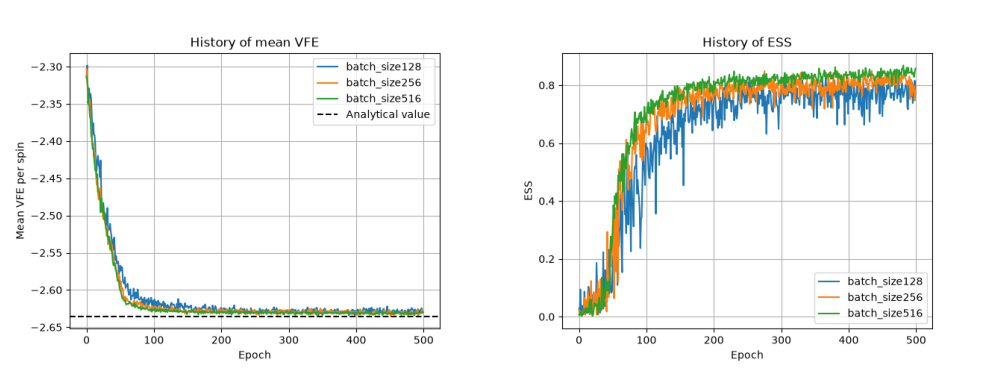

In [42]:
img1 = mpimg.imread("../results/figures/hiperparam_test/Batch size (pixelcnn)_vfe.png")
img2 = mpimg.imread("../results/figures/hiperparam_test/Batch size (pixelcnn)_ESS.png")

fig, axes = plt.subplots(1, 2, figsize=(10, 8))

axes[0].imshow(img1)
axes[1].imshow(img2)

for ax in axes.flat:
    ax.axis("off")

plt.tight_layout()
plt.show()

The figures show how batch size affects the VFE and ESS of the PixelCNN model.

Models with larger batch size converge slighlty faster to analytical value in mean VFE figure

Configurations with largest batch size achieve slighty larger ESS over training.

In [43]:
pixelcnn_analysis.loc[['batch_size128', 'batch_size256', 'batch_size516'], ['Mean_vfe', 'Std_vfe', 'VFE_abs_err', 'Mean_ESS', 'Std_ESS']]

,Mean_vfe,Std_vfe,VFE_abs_err,Mean_ESS,Std_ESS
Model,,,,,
batch_size128,-2.626698,0.002968,0.009204,0.727551,0.028851
batch_size256,-2.630681,0.001458,0.005222,0.812827,0.017667
batch_size516,-2.630944,0.001057,0.004959,0.836761,0.009009


The numerical results confirm that increasing the batch size improves both VFE accuracy and ESS.

Batch size 516 achieves the lowest VFE error (`0.00496`) and the highest mean ESS (`0.8368`).

Larger batch sizes also reduce variability in both VFE and ESS.

Overall, batch size 516 provides the best performance among the tested configurations.

#### Overall most promising configuration

Based on the individual hyperparameter experiments, the most promising configuration is:

- Batch size: 516
- Kernel size: 7
- Number of channels: 64

## LSTM

batch_size
learning_rate
Spin_placement_info

In [44]:
lstm_analysis = pd.read_csv('../results/tables/hiperparam_test/LSTM.csv')
lstm_analysis["Model"] = lstm_analysis["Model"].str.strip(to_strip="[]''")
lstm_analysis.set_index("Model", inplace=True)
lstm_analysis

,Mean_vfe,Std_vfe,VFE_abs_err,Mean_ESS,Std_ESS,Nb_of_params,Time_to_generate_samples,Training epochs
Model,,,,,,,,
batch_size128,-2.594935,0.005548,0.040968,0.271771,0.093188,9046,0.461164,500
batch_size512,-2.605185,0.002565,0.030718,0.355114,0.056875,9046,0.486281,500
batch_size1024,-2.607655,0.001733,0.028248,0.394656,0.022422,9046,0.490842,500
spin_info_false,-2.590678,0.005152,0.045224,0.252279,0.083639,8686,0.410990,500
spin_info_true,-2.593997,0.005847,0.041905,0.295572,0.081573,9046,0.465917,500
learning_rate01,-2.504699,0.010728,0.131204,0.065233,0.037615,9046,0.461131,500
learning_rate001,-2.592474,0.006839,0.043428,0.308220,0.046346,9046,0.459919,500
learning_rate0001,-2.566772,0.008040,0.069131,0.175659,0.053074,9046,0.465314,500


#### Analysis of batch size

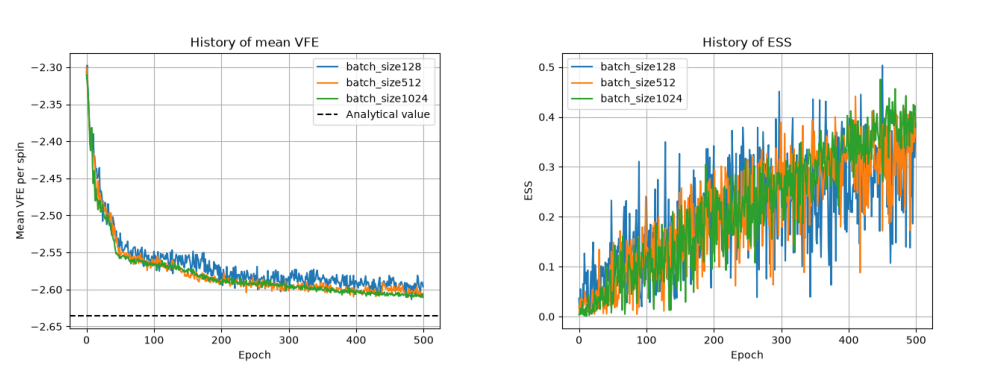

In [45]:
img1 = mpimg.imread("../results/figures/hiperparam_test/Batch size (lstm)_vfe.png")
img2 = mpimg.imread("../results/figures/hiperparam_test/Batch size (lstm)_ESS.png")

fig, axes = plt.subplots(1, 2, figsize=(10, 8))

axes[0].imshow(img1)
axes[1].imshow(img2)

for ax in axes.flat:
    ax.axis("off")

plt.tight_layout()
plt.show()

The training curves show an effect of batch size on both convergence stability and sample quality.

For VFE, all three configurations improve rapidly during the first 50–100 epochs and then converge more gradually. Batch sizes 512 and 1024 produce smoother curves and achieve slightly lower final VFE values than batch size 128.

For ESS, all configurations improve throughout training, but batch size 128 shows noticeably larger fluctuations. Batch sizes 512 and 1024 are more stable, with batch size 1024 reaching the highest ESS values near the end of training.

In [46]:
lstm_analysis.loc[['batch_size128', 'batch_size512', 'batch_size1024'], ['Mean_vfe', 'Std_vfe', 'VFE_abs_err', 'Mean_ESS', 'Std_ESS']]

,Mean_vfe,Std_vfe,VFE_abs_err,Mean_ESS,Std_ESS
Model,,,,,
batch_size128,-2.594935,0.005548,0.040968,0.271771,0.093188
batch_size512,-2.605185,0.002565,0.030718,0.355114,0.056875
batch_size1024,-2.607655,0.001733,0.028248,0.394656,0.022422


The numerical results confirm the trends observed in the training curves.

Increasing the batch size improves both VFE accuracy and ESS. Batch size 1024 achieves the lowest VFE error (`0.0282`) and the highest mean ESS (`0.3947`).

Larger batch sizes also reduce variability in both VFE and ESS.

Overall, batch size 1024 provides the best performance among the tested configurations.

#### Analysis of spin information

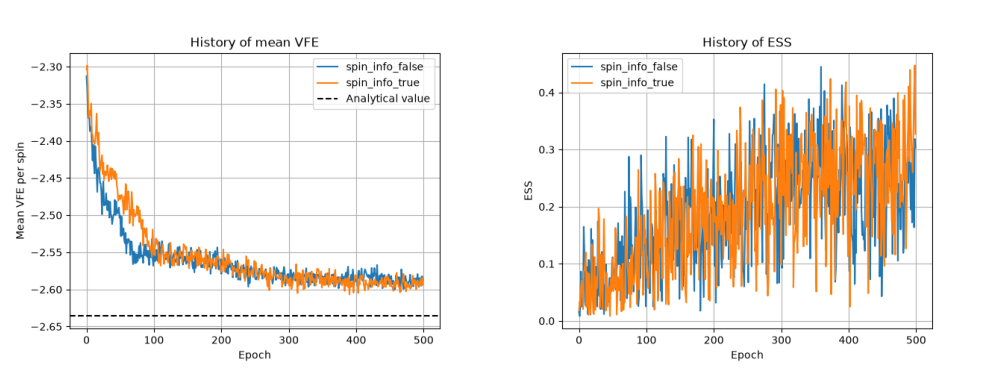

In [47]:
img1 = mpimg.imread("../results/figures/hiperparam_test/Spin Information (lstm)_vfe.png")
img2 = mpimg.imread("../results/figures/hiperparam_test/Spin Information (lstm)_ESS.png")

fig, axes = plt.subplots(1, 2, figsize=(10, 8))

axes[0].imshow(img1)
axes[1].imshow(img2)

for ax in axes.flat:
    ax.axis("off")

plt.tight_layout()
plt.show()

The plots compare two LSTM configurations: one without explicit spin-position information (`spin_info_false`) and one with positional information provided to the model (`spin_info_true`).

For VFE, both models improve rapidly during the first approximately 100 epochs and then converge more gradually. The model without positional information reaches lower VFE values slightly faster during the early stage of training. However, after roughly 150–200 epochs, the two curves become very similar and converge to almost the same final region.

This suggests that explicit spin-position information may affect the early training dynamics, but it does not appear to provide a substantial advantage in the final VFE under the tested configuration.

The ESS curves show a similar pattern. Both models gradually achieve higher ESS values during training, but the curves are highly noisy and overlap strongly throughout most of the experiment.

In [48]:
lstm_analysis.loc[['spin_info_false', 'spin_info_true'], ['Mean_vfe', 'Std_vfe', 'VFE_abs_err', 'Mean_ESS', 'Std_ESS']]

,Mean_vfe,Std_vfe,VFE_abs_err,Mean_ESS,Std_ESS
Model,,,,,
spin_info_false,-2.590678,0.005152,0.045224,0.252279,0.083639
spin_info_true,-2.593997,0.005847,0.041905,0.295572,0.081573


The results show only small differences between the two configurations.

Adding spin-position information slightly improves VFE accuracy (`0.0419` vs `0.0452`) and increases mean ESS (`0.2956` vs `0.2523`).

The differences in variability are minimal, with very similar VFE and ESS standard deviations.

Overall, spin-position information provides a modest improvement in model performance.

#### Analysis of Learning rate

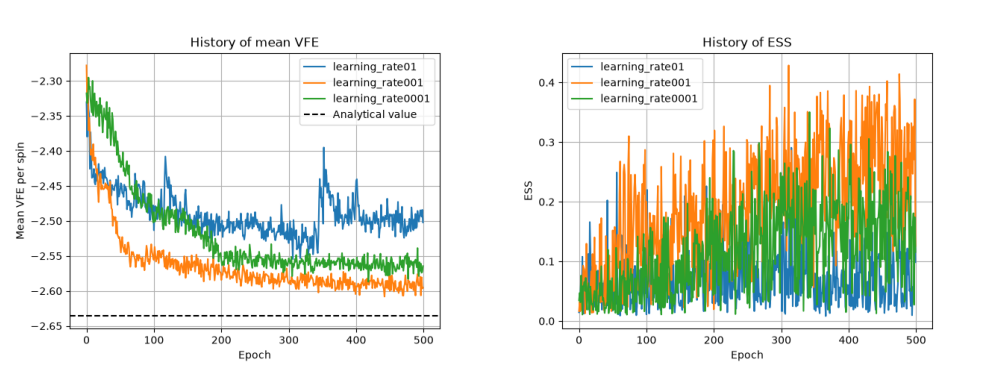

In [49]:
img1 = mpimg.imread("../results/figures/hiperparam_test/Learning rate (lstm)_vfe.png")
img2 = mpimg.imread("../results/figures/hiperparam_test/Learning rate (lstm)_ESS.png")

fig, axes = plt.subplots(1, 2, figsize=(10, 8))

axes[0].imshow(img1)
axes[1].imshow(img2)

for ax in axes.flat:
    ax.axis("off")

plt.tight_layout()
plt.show()

The figures compare how different learning rates affect the overall convergence of the model. The tested learning rates are 0.1 (`learning_rate01`), 0.01 (`learning_rate001`) and 0.001 (`learning_rate0001`).

The learning rate of 0.01 provides the best convergence among the tested configurations. During the first approximately 80 epochs, the model improves rapidly and then continues to converge more gradually toward the analytical value.

The learning rate of 0.001 produces a smoother and more stable training curve. However, it converges more slowly than the 0.01 configuration, which results in a worse approximation after 500 epochs.

The learning rate of 0.1 shows unstable training behaviour, with large fluctuations and a noticeably higher final VFE.

A similar trend is visible in ESS. The learning rate of 0.01 achieves the highest ESS values overall, while the 0.1 configuration achieves the lowest. The ESS for the 0.001 learning rate increases steadily during training, but more slowly than for the 0.01 configuration.

In [50]:
lstm_analysis.loc[['learning_rate01', 'learning_rate001', 'learning_rate0001'], ['Mean_vfe', 'Std_vfe', 'VFE_abs_err', 'Mean_ESS', 'Std_ESS']]

,Mean_vfe,Std_vfe,VFE_abs_err,Mean_ESS,Std_ESS
Model,,,,,
learning_rate01,-2.504699,0.010728,0.131204,0.065233,0.037615
learning_rate001,-2.592474,0.006839,0.043428,0.308220,0.046346
learning_rate0001,-2.566772,0.008040,0.069131,0.175659,0.053074


The numerical results confirm the trends observed in the training curves.

The learning rate of 0.01 performs best, achieving the lowest VFE error (`0.0434`) and the highest mean ESS (`0.3082`).

The learning rate of 0.1 performs worst, with a much higher VFE error and the lowest ESS (`0.0652`).

The learning rate of 0.001 gives intermediate results, with slower convergence and mean ESS of `0.1757`.

Overall, 0.01 provides the best performance among the tested learning rates.

#### Overal most promising configuration

Based on the individual hyperparameter experiments, the most promising configuration is:

- Batch size: 1024
- Learning rate: 0.01
- Information about spin placement: True

## VAN

  batch_size: 512
  learning_rate: 0.1
  nb_layers: 2

In [51]:
van_analysis = pd.read_csv('../results/tables/hiperparam_test/VAN.csv')
van_analysis["Model"] = van_analysis["Model"].str.strip(to_strip="[]''")
van_analysis.set_index("Model", inplace=True)
van_analysis

,Mean_vfe,Std_vfe,VFE_abs_err,Mean_ESS,Std_ESS,Nb_of_params,Time_to_generate_samples,Training epochs
Model,,,,,,,,
batch_size256,-2.612553,0.002961,0.023349,0.437839,0.101862,8320,0.292473,1024
batch_size512,-2.634433,0.000502,0.001470,0.948480,0.003386,8320,0.289817,1024
batch_size1024,-2.635687,0.000148,0.000215,0.991201,0.000797,8320,0.290832,1024
learning_rate01,-2.634586,0.000584,0.001317,0.952049,0.002824,8320,0.289900,1024
learning_rate001,-2.634599,0.000537,0.001304,0.954261,0.002934,8320,0.290850,1024
learning_rate0001,-2.563539,0.003714,0.072364,0.106929,0.050999,8320,0.289700,1024
num_layers1,-2.549226,0.004236,0.086677,0.073095,0.038537,4160,0.229741,1024
num_layers2,-2.634916,0.000445,0.000986,0.964569,0.003460,8320,0.293859,1024
num_layers4,-2.189535,0.003898,0.446368,0.038469,0.027929,16640,0.400870,1024


#### Analysis of Batch Size

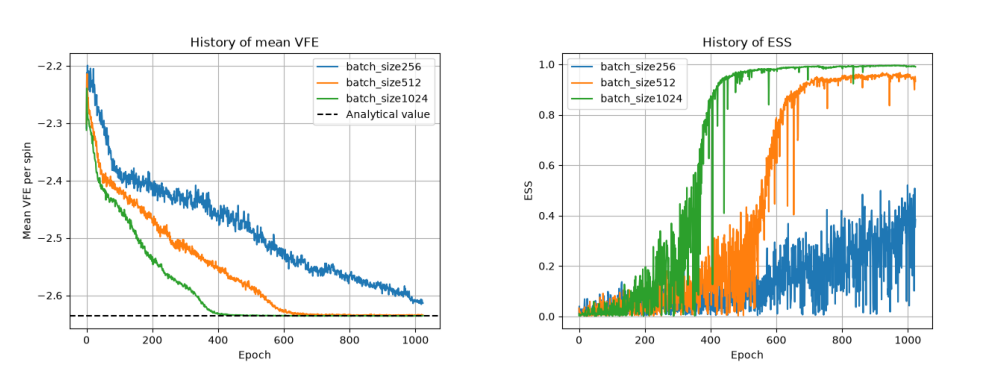

In [52]:
img1 = mpimg.imread("../results/figures/hiperparam_test/Batch size (van)_vfe.png")
img2 = mpimg.imread("../results/figures/hiperparam_test/Batch size (van)_ESS.png")

fig, axes = plt.subplots(1, 2, figsize=(10, 8))

axes[0].imshow(img1)
axes[1].imshow(img2)

for ax in axes.flat:
    ax.axis("off")

plt.tight_layout()
plt.show()

The figures show how batch size affects the training behaviour of the Variational Autoregressive Network in terms of variational free energy and effective sample size.

Smaller batch sizes result in noticeably less stable training, with larger fluctuations in both VFE and ESS.

Among the tested configurations, the model with batch size 1024 converges the fastest toward the analytical VFE value and reaches the highest ESS. The batch size 512 configuration also converges well, but more slowly, while batch size 256 shows the slowest convergence and the lowest ESS throughout most of the training.

In [53]:
van_analysis.loc[['batch_size256', 'batch_size512', 'batch_size1024'], ['Mean_vfe', 'Std_vfe', 'VFE_abs_err', 'Mean_ESS', 'Std_ESS']]

,Mean_vfe,Std_vfe,VFE_abs_err,Mean_ESS,Std_ESS
Model,,,,,
batch_size256,-2.612553,0.002961,0.023349,0.437839,0.101862
batch_size512,-2.634433,0.000502,0.001470,0.948480,0.003386
batch_size1024,-2.635687,0.000148,0.000215,0.991201,0.000797


The numerical results confirm the trends observed in the training curves.

Increasing the batch size strongly improves both VFE accuracy and ESS. Batch size 1024 achieves the lowest VFE error (`0.000215`) and the highest mean ESS (`0.9912`).

Larger batch sizes also substantially reduce the variability of both VFE and ESS.

Overall, batch size 1024 provides the best performance among the tested configurations.

#### Analysis of Number of Layers

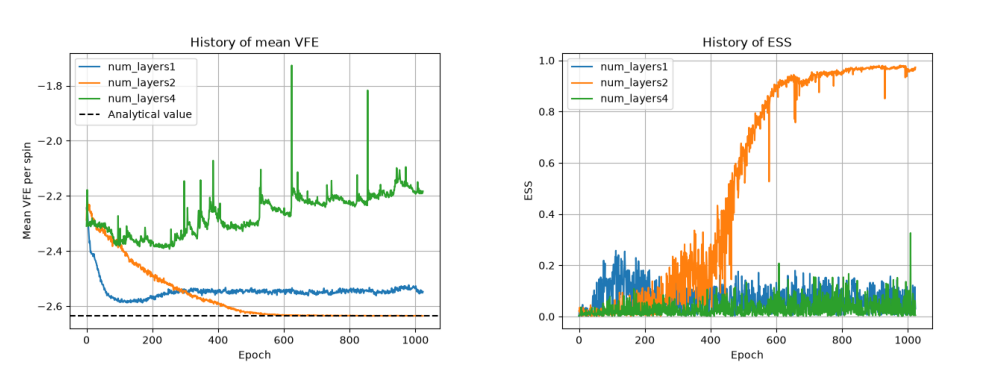

In [54]:
img1 = mpimg.imread("../results/figures/hiperparam_test/Number of layers (van)_vfe.png")
img2 = mpimg.imread("../results/figures/hiperparam_test/Number of layers (van)_ESS.png")

fig, axes = plt.subplots(1, 2, figsize=(10, 8))

axes[0].imshow(img1)
axes[1].imshow(img2)

for ax in axes.flat:
    ax.axis("off")

plt.tight_layout()
plt.show()

The figures show how the number of hidden layers affects VAN training.

The model with 2 layers clearly performs best. Its VFE gradually converges toward the analytical value, while ESS increases to almost 1.

The 1-layer model improves rapidly at the beginning but then reaches a plateau with noticeably worse VFE and low ESS.

The 4-layer model is highly unstable and fails to converge, showing large VFE fluctuations and consistently low ESS.

In [55]:
van_analysis.loc[['num_layers1', 'num_layers2', 'num_layers4'], ['Mean_vfe', 'Std_vfe', 'VFE_abs_err', 'Mean_ESS', 'Std_ESS']]

,Mean_vfe,Std_vfe,VFE_abs_err,Mean_ESS,Std_ESS
Model,,,,,
num_layers1,-2.549226,0.004236,0.086677,0.073095,0.038537
num_layers2,-2.634916,0.000445,0.000986,0.964569,0.003460
num_layers4,-2.189535,0.003898,0.446368,0.038469,0.027929


The numerical results confirm the behaviour observed in the training curves.

The 2-layer model achieves the lowest VFE error (`0.000986`) and the highest mean ESS (`0.9646`). It also has the lowest VFE variability (`0.000445`).

The 1-layer model performs substantially worse, with a VFE error of `0.0867` and mean ESS of `0.0731`.

The 4-layer model performs the worst, with a very large VFE error (`0.4464`) and the lowest mean ESS (`0.0385`).

Overall, 2 layers provide the best performance among the tested configurations.

#### Analysis of Learning Rate

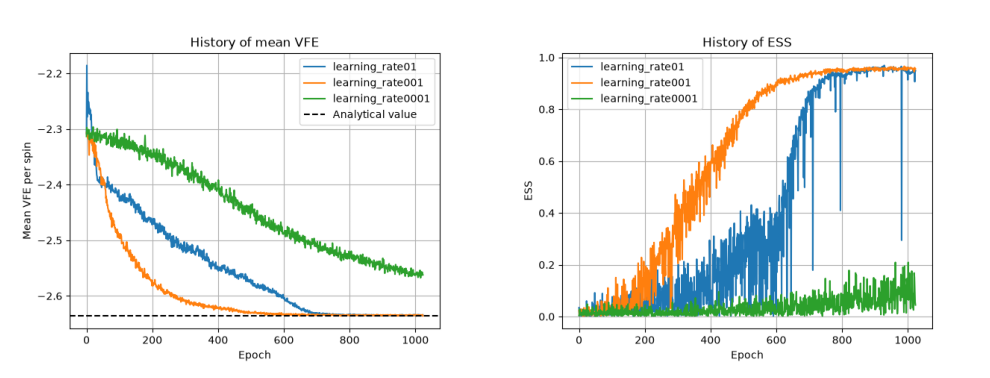

In [56]:
img1 = mpimg.imread("../results/figures/hiperparam_test/Learning rate (van)_vfe.png")
img2 = mpimg.imread("../results/figures/hiperparam_test/Learning rate (van)_ESS.png")

fig, axes = plt.subplots(1, 2, figsize=(10, 8))

axes[0].imshow(img1)
axes[1].imshow(img2)

for ax in axes.flat:
    ax.axis("off")

plt.tight_layout()
plt.show()

The figures show how the learning rate affects VAN training.

Learning rates of 0.1 and 0.01 both converge close to the analytical VFE value and achieve high ESS. The 0.01 configuration converges faster and more smoothly.

The learning rate of 0.001 is too small in this setup, resulting in much slower convergence and consistently low ESS.

In [57]:
van_analysis.loc[['learning_rate01', 'learning_rate001', 'learning_rate0001'], ['Mean_vfe', 'Std_vfe', 'VFE_abs_err', 'Mean_ESS', 'Std_ESS']]

,Mean_vfe,Std_vfe,VFE_abs_err,Mean_ESS,Std_ESS
Model,,,,,
learning_rate01,-2.634586,0.000584,0.001317,0.952049,0.002824
learning_rate001,-2.634599,0.000537,0.001304,0.954261,0.002934
learning_rate0001,-2.563539,0.003714,0.072364,0.106929,0.050999


The numerical results confirm the trends observed in the training curves.

Learning rates of 0.1 and 0.01 achieve very similar final results, with VFE errors close to `0.0013` and mean ESS around `0.95`.

The 0.001 configuration performs substantially worse, with a much larger VFE error (`0.0724`) and mean ESS of only `0.1069`.

Overall, 0.01 provides the best balance between convergence speed and final model quality among the tested values.

#### Overal most promising configuration

Based on the individual hyperparameter experiments, the most promising configuration is:

- Batch size: 1024
- Number of layers: 2
- Learning rate: 0.01

# Conclusions

The experiments show that all tested autoregressive architectures are capable of learning a distribution close to the target Boltzmann distribution. They however differ significantly in convergence speed, sampling quality and computational cost.

Among the tested architectures, VAN achieved the best overall trade-off. It reached the lowest VFE error, the highest mean ESS, used the fewest parameters and generated samples the fastest.

The Transformer also achieved very strong final results, especially in terms of ESS and VFE accuracy. However, it had the slowest sample generation time.

LSTM produced competitive final results while remaining relatively lightweight. Its main limitation was slower convergence and lower sampling quality compared with VAN and Transformer.

PixelCNN converged quickly during the early stages of training, but despite having the largest number of parameters, its final ESS and VFE accuracy were slightly worse than those of the other architectures.

The hyperparameter experiments also showed that training configuration has a strong influence on model performance. Larger batch sizes generally improved stability and ESS, while an intermediate learning rate usually provided the best balance between convergence speed and training stability. Increasing model capacity, such as the number of layers or channels, did not always improve final performance.

Overall, the results indicate that model architecture alone does not determine sampling quality. Hyperparameter selection is equally important when choosing an autoregressive model for Boltzmann sampling.

For this experimental setup, VAN provided the most efficient combination of accuracy, sample quality and time to generate 10 samples, while the Transformer offered similarly strong modelling quality at a higher computational expense.

The conclusions are specific to the tested lattice size, temperature, training budget and hyperparameter ranges, so further experiments would be required to determine whether the same behaviour holds for larger or more complex systems.